# 1 Value-at-Risk

**Value at Risk - VaR** - is one of the most important metrics that is used to measure the risk associated with a financial position or a portfolio of financial instruments. VaR can be defined as the maximum loss with a confidence level over a predetermined period. Let's say that the **1-day 95% VaR** of our portfolio is **$100**.

This means that 95% of the time, it is expected that - under normal market conditions - we will not lose more than $100 by holding our portfolio over one day.

Three approaches that are commonly used in the industry are:

- **Parametric**
- **Historical Simulation**
- **Monte Carlo Siui**mulation

# 2.1 Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np
from numpy.linalg import multi_dot
from scipy.stats import norm
from tabulate import tabulate

# Import matplotlib for visualization
import matplotlib
import matplotlib.pyplot as plt

# Plot settings
plt.style.use('ggplot')
matplotlib.rcParams['figure.figsize'] = [12.0, 8.0]
matplotlib.rcParams['font.size'] = 10
matplotlib.rcParams['lines.linewidth'] = 2.0
# from helper import plot_var

# 2.2 Retrieve Data

We will use the FAANG stocks as before to build for calculation of VaR.

In [2]:
# Load locally stored data
df = pd.read_csv('faang_stocks.csv', parse_dates=True, index_col=0)

# Check first 5 values
df.head()

,AAPL,AMZN,GOOG,META,NFLX
Date,,,,,
2015-01-02,24.347168,15.4260,26.074963,78.151466,49.848572
2015-01-05,23.661274,15.1095,25.531416,76.896263,47.311428
2015-01-06,23.663498,14.7645,24.939672,75.860229,46.501431
2015-01-07,23.995317,14.9210,24.896942,75.860229,46.742859
2015-01-08,24.917265,15.0230,24.975445,77.882492,47.779999


In [3]:
df.tail(2)

,AAPL,AMZN,GOOG,META,NFLX
Date,,,,,
2021-07-20,143.370163,178.659500,130.632126,340.359833,531.049988
2021-07-21,142.634399,179.259995,132.125748,344.912476,513.630005


# 2.3 Calculate Returns

In [4]:
# Calculate daily returns
returns = df.pct_change().dropna()

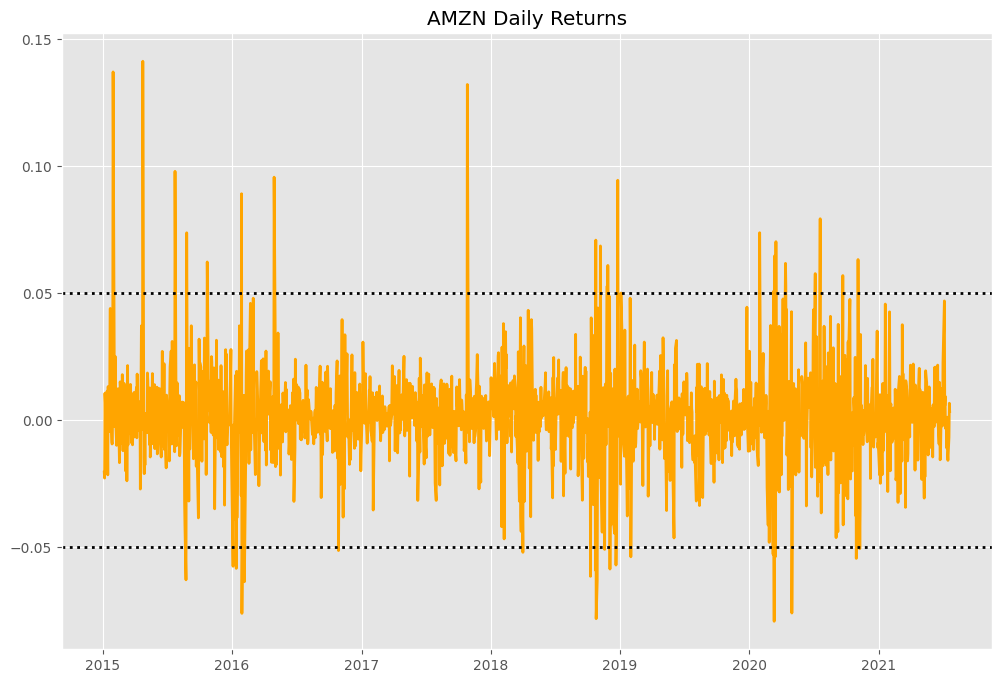

In [5]:
# Visualize AMZN daily returns
plt.plot(returns['AMZN'], color='orange')
plt.axhline(y=0.05, ls='dotted', color='black')
plt.axhline(y=-0.05, ls='dotted', color='black')
plt.title('AMZN Daily Returns')
plt.grid(True)

# 2.4 Parametric VaR

The Variance-covariance is a parametric method which assumes (almost always) that the returns are normally distributed. In this method, we first calculate the mean and standard deviation of the returns to derive the risk metric. Based on the assumption of normality, we can generalise:

$$
VaR = \text{position} \times (\mu - z \times \sigma)
$$

Where:
- $\mu$ is the return
- $\sigma$ is the volatility
- z is the number of standard deviations from the mean

### Confidence Level and Value at Risk
| Confidence Level | Value At Risk        |
|------------------|----------------------|
| 90%              | \( $\mu$ - 1.29 $\sigma$ \) |
| 95%              | \( $\mu$ - 1.64 $\sigma$ \) |
| 99%              | \( $\mu$ - 2.33 $\sigma$ \) |

---

In [6]:
# Calculate mean and standard deviation
mean = np.mean(returns['AMZN'])
stdev = np.std(returns['AMZN'])

# Calculate VaR at difference confidence level
VaR_90 = norm.ppf(1-0.90,mean,stdev)
VaR_95 = norm.ppf(1-0.95,mean,stdev) #norm.ppf(0.05)
VaR_99 = norm.ppf(1-0.99,mean,stdev)

In [7]:
VaR_99

-0.042928312014931226

In [8]:
norm.ppf(0.01)

-2.3263478740408408

In [9]:
# Ouput results in tabular format
table = [['90%', VaR_90],['95%', VaR_95],['99%', VaR_99] ]
header = ['Confidence Level', 'Value At Risk']
print(tabulate(table,headers=header))

Confidence Level      Value At Risk
------------------  ---------------
90%                      -0.0228979
95%                      -0.029863
99%                      -0.0429283


Lets now define a VaR function so that we can use it calculate it for individual stocks.

## 2.4.1 UDF : User Defined Function

In [10]:
def plot_var():
    confidence_level=0.95
    z = norm.ppf(1-confidence_level)
    x = np.arange(-6, 6, 0.1)
    x2 = np.arange(-6, z, 1/40.)
    
    note1 = 'Red area to the left of the'
    note2 = 'dotted red line represents'
    note3 = '5% of the total area'
    note4 = 'The curve represents a profit/loss'
    note5 = 'density function. The 5% VaR is'
    note6 = '1.64 standard deviation from the mean'
    
    plt.figure(figsize=(8, 6))
    plt.plot(x, norm.pdf(x, 0, 1), color='orange')
    plt.ylim(0, 0.5)
    plt.axvline(x=z, ymin=0, ymax=1, linewidth=2, ls='dotted', color='red')
    plt.fill_between(x2, norm.pdf(x2, 0, 1), color='red')
    plt.figtext(0.14, 0.5, note1)
    plt.figtext(0.14, 0.47, note2)
    plt.figtext(0.14, 0.44, note3)
    plt.figtext(0.5, 0.85, note4)
    plt.figtext(0.5, 0.82, note5)
    plt.figtext(0.5, 0.79, note6)
    
    plt.annotate("", xy=(-2.5, 0.08), xytext=(-2.5, 0.18), arrowprops=dict(facecolor='red', shrink=0.001))
    plt.annotate('z = ' + str(np.around(z, 2)), xy = (-1.5, 0.05))
    plt.title('VaR at 95% confidence level')

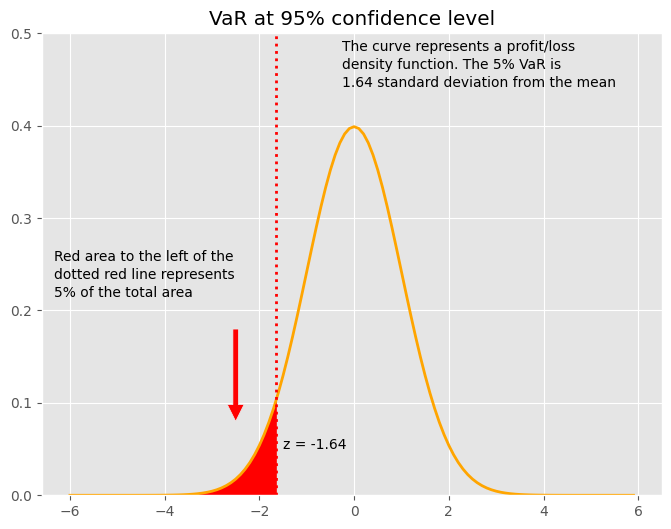

In [11]:
plot_var()

In [12]:
# VaR function
def VaR(symbol, cl=0.95):
    mean = np.mean(returns[symbol])
    stdev = np.std(returns[symbol])
    return np.around(norm.ppf(1-cl,mean,stdev),4)

In [13]:
norm.ppf(1-0.95,mean,stdev)

-0.029862984158728543

In [14]:
# VaR for stocks
print('VaR for FAANG Stocks')
print('---'*11)
[print(f'VaR at 95% CL for {stock:4} : {VaR(stock) * 100:0.4}%') for stock in df.columns][0]

VaR for FAANG Stocks
---------------------------------
VaR at 95% CL for AAPL : -2.93%
VaR at 95% CL for AMZN : -2.99%
VaR at 95% CL for GOOG : -2.66%
VaR at 95% CL for META : -3.17%
VaR at 95% CL for NFLX : -4.18%


Now, let's assume that we have 1,000 shares of AMZN's stock on Dec 30, 2020. What is the maximum loss next day with a confidence level of 99%?

In [15]:
num_of_shares = 1000
price = df['AMZN'].iloc[-1]
position = num_of_shares * price
amzn_var = position * VaR_99
print(f'Amazon Holding Value: {position}')
print(f'Amazon VaR at 99% confidence level is: {amzn_var}')

Amazon Holding Value: 179259.99450683594
Amazon VaR at 99% confidence level is: -7695.328975984311


VaR can also be calculated using the above formula at 99% confidence level.

In [16]:
# VaR calculation by appling direct formulae
position * (mean + norm.ppf(1-0.99) * stdev) # mean-2.33*stdev

-7695.328975984311

# 2.5 Scaling VaR

Now, let's calculate VaR over a 5-day period. To scale it, multiply by square root of time.

$$ VaR = position * (\mu - z * \sigma) * \sqrt{T}$$

where, $T$ is the horizon or forecast period.

In [17]:
forecast_days = 5
f_VaR_90 = VaR_90*np.sqrt(forecast_days)
f_VaR_95 = VaR_95*np.sqrt(forecast_days)
f_VaR_99 = VaR_99*np.sqrt(forecast_days)

In [18]:
ftable = [['90%', f_VaR_90],['95%', f_VaR_95],['99%', f_VaR_99] ]
fheader = ['Confidence Level', '5-Day Forecast Value At Risk']
print(tabulate(ftable,headers=fheader))

Confidence Level      5-Day Forecast Value At Risk
------------------  ------------------------------
90%                                     -0.0512013
95%                                     -0.0667757
99%                                     -0.0959906


Let's now calculate AMZN VaR over a 5-day period with a confidence level of 99%

In [19]:
amzn_var_5days = position * f_VaR_99
print(f'Amazon Holding Value: {position}')
print(f'Amazon VaR at 99% confidence level is: {amzn_var_5days}')

Amazon Holding Value: 179259.99450683594
Amazon VaR at 99% confidence level is: -17207.278699524766


Text(0.5, 1.0, 'VaR_95 Scaled by Time')

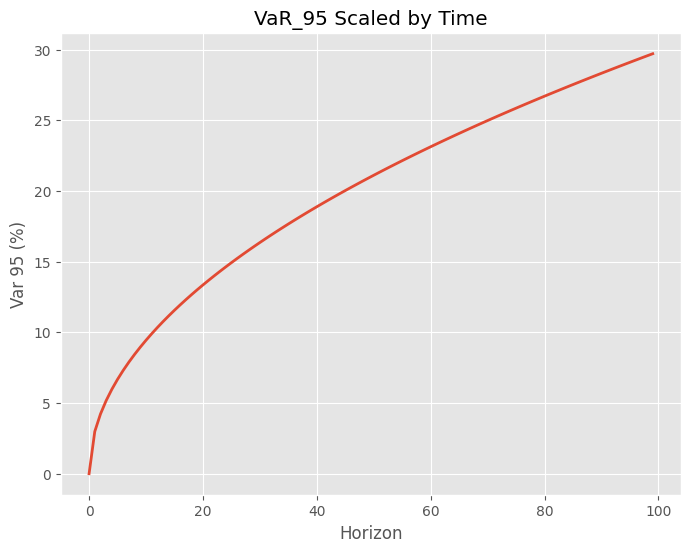

In [20]:
# Scaled VaR over different time horizon
plt.figure(figsize=(8,6))
plt.plot(range(100),[-100*VaR_95*np.sqrt(x) for x in range(100)])
plt.xlabel('Horizon')
plt.ylabel('Var 95 (%)')
plt.title('VaR_95 Scaled by Time')

# 2.6 Historical VaR

Asset returns do not necessarily follow a normal distribution. An alternative is to use sorted returns to evaluate a VaR. This method uses historical data where returns are sorted in ascending order to calculate maximum possible loss for a given confidence level.

In [21]:
# Use quantile function for Historical VaR
hVaR_90 = returns['AMZN'].quantile(0.10)
hVaR_95 = returns['AMZN'].quantile(0.05)
hVaR_99 = returns['AMZN'].quantile(0.01)

In [22]:
htable = [['90%', hVaR_90],['95%', hVaR_95],['99%', hVaR_99]]
print(tabulate(htable,headers=header))

Confidence Level      Value At Risk
------------------  ---------------
90%                      -0.0181984
95%                      -0.0279399
99%                      -0.0524812


# 2.7 Expected Short Fall

VaR is a reasonable measure of risk if assumption of normality holds. Else, we might underestimate the risk if we observe a fat tail or overestimate the risk if tail is thinner. Expected shortfall or Conditional Value at Risk - CVaR - is an estimate of expected shortfall sustained in the worst 1 - x% of scenarios. It is defined as the average loss based on the returns that are lower than the VaR threshold. Assume that we have n return observations, then the expected shortfall is

$$ CVaR = \frac 1 n * \sum_{i=1}^{n} R_i[R \leq hVaR_{cl}]$$

where, $R$ is returns, $hVaR$ is historical VaR and $cl$ is the confidence level.

In [23]:
# Calculate CVar
CVaR_90 = returns['AMZN'][returns['AMZN']<=hVaR_90].mean()
CVaR_95 = returns['AMZN'][returns['AMZN']<=hVaR_95].mean()
CVaR_99 = returns['AMZN'][returns['AMZN']<=hVaR_99].mean()

In [24]:
ctable = [['90%', CVaR_90],['95%', CVaR_95],['99%', CVaR_99]]
cheader = ['Confidence Level', 'Conditional Value At Risk']
print(tabulate(ctable,headers=cheader))

Confidence Level      Conditional Value At Risk
------------------  ---------------------------
90%                                  -0.0321076
95%                                  -0.0418939
99%                                  -0.0627299


# 2.8 MonteCarlo VaR

The Monte Carlo simulation approach has a number of similarities to historical simulation. It allows us to use actual historical distributions rather than having to assume normal returns. As returns are assumed to follow a normal distribution, we could generate n simulated returns with the same mean and standard deviation (derived from the daily returns) and then sorted in ascending order to calculate maximum possible loss for a given confidence level.

In [25]:
# Set seed for reproducibility
np.random.seed(42)

# Number of simulations
n_sims = 5000

# Simulate returns and sort
sim_returns = np.random.normal(mean, stdev, n_sims)

# Use percentile function for MCVaR
MCVaR_90 = np.percentile(sim_returns,10)
MCVaR_95 = np.percentile(sim_returns, 5)
MCVaR_99 = np.percentile(sim_returns,1)

In [26]:
mctable = [['90%', MCVaR_90],['95%', MCVaR_95],['99%', MCVaR_99]]
print(tabulate(mctable,headers=header))

Confidence Level      Value At Risk
------------------  ---------------
90%                      -0.0226649
95%                      -0.0292646
99%                      -0.0436314


# 3 Portfolio VaR

If we know the returns and volatilities of all the assets in the portfolio, we can calculate the VaR for the whole portfolio. We will now derive VaR of an equal weighted portfolio of FAANG stocks.

## 3.1 Assign Weights

In [27]:
# Weights from Minimum Variance Portfolio
# wts = np.array([28.35, 17.41, 8.63, 42.57, 3.05])/100.
wts = np.array([20, 20, 20, 20, 20])/100.
wts = wts[:, np.newaxis]
wts

array([[0.2],
       [0.2],
       [0.2],
       [0.2],
       [0.2]])

In [28]:
# Subsume position into a dataframe
shares = pd.DataFrame((wts * 1000).astype(int), index=df.columns, columns =['quantity'])
shares['price'] = df.iloc[-1]
shares['pos'] = shares.quantity * shares.price
shares

,quantity,price,pos
AAPL,200,142.634399,28526.879883
AMZN,200,179.259995,35851.998901
GOOG,200,132.125748,26425.149536
META,200,344.912476,68982.495117
NFLX,200,513.630005,102726.000977


## 3.2 Portfolio return

In [29]:
# Portfolio returns
port_ret = np.dot(returns, wts)
port_mean = port_ret.mean()
port_mean

0.001381452424981214

## 3.3 Portfolio Volatility

In [30]:
# Portfolio volatility
port_stdev = np.sqrt(multi_dot([wts.T, returns.cov(), wts]))
port_stdev.flatten()[0]

0.016081955198800183

## 3.4 Portfolio VaR

In [31]:
# Calculate Portfolio VaR at difference confidence level
pVaR_90 = norm.ppf(1-0.90,port_mean,port_stdev).flatten()[0]
pVaR_95 = norm.ppf(1-0.95,port_mean,port_stdev).flatten()[0]
pVaR_99 = norm.ppf(1-0.99,port_mean,port_stdev).flatten()[0]

In [32]:
# Ouput results in tabular format
ptable = [['90%', pVaR_90],['95%', pVaR_95],['99%', pVaR_99]]
header = ['Confidence Level', 'Value At Risk']
print(tabulate(ptable,headers=header))

Confidence Level      Value At Risk
------------------  ---------------
90%                      -0.0192284
95%                      -0.025071
99%                      -0.0360308


Let's now compare the portfolio VaR numbers with that of the individual stocks.

In [33]:
# Iterate over symbols
for stock in df.columns:
    pos = df[stock].iloc[-1] * shares.T[stock]['quantity']
    pvar = VaR(stock)
    print(f'{stock} Holding Value: {pos:0.8}')
    print(f'{stock} VaR at 95% confidence level: {100*pvar:0.8}%')
    print()
print(f'Portfolio Holding Value: {shares.pos.sum():0.8}')
print(f'Portoflio VaR at 95% confidence level: {100*pVaR_95:0.3}%')

AAPL Holding Value: 28526.88
AAPL VaR at 95% confidence level: -2.93%

AMZN Holding Value: 35851.999
AMZN VaR at 95% confidence level: -2.99%

GOOG Holding Value: 26425.15
GOOG VaR at 95% confidence level: -2.66%

META Holding Value: 68982.495
META VaR at 95% confidence level: -3.17%

NFLX Holding Value: 102726.0
NFLX VaR at 95% confidence level: -4.18%

Portfolio Holding Value: 262512.52
Portoflio VaR at 95% confidence level: -2.51%


# References

* Scipy* 
Tabulate** Paul Wilmott (2007), Paul Wilmott introduces Quantitative Finance